In [1]:
#!pip install nixtla

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.6 MB/s eta 0:00:00


In [3]:
#pip install zstandard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.7/633.7 kB 5.6 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


# 1 Set Up API

In [1]:
from dotenv import load_dotenv
load_dotenv()

from nixtla import NixtlaClient
nixtla_client = NixtlaClient()

nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

# 2 Import Data

In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


<font size="3">Date as string can’t be processed. <font>

In [3]:
df_copy = df.copy()
df_copy['date'] = pd.to_datetime(df_copy['date'])
df_copy.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


# 3 Visualise Data

In [4]:
df_copy['country'].unique()

array(['Canada', 'Finland', 'Italy', 'Kenya', 'Norway', 'Singapore'],
      dtype=object)

In [5]:
df_Can = df_copy[df_copy['country']=='Canada']
df_Can

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0
...,...,...,...,...,...,...
230050,230050,2016-12-31,Canada,Premium Sticker Mart,Holographic Goose,309.0
230051,230051,2016-12-31,Canada,Premium Sticker Mart,Kaggle,2170.0
230052,230052,2016-12-31,Canada,Premium Sticker Mart,Kaggle Tiers,1711.0
230053,230053,2016-12-31,Canada,Premium Sticker Mart,Kerneler,938.0


In [6]:
df_Can['store'].unique()

array(['Discount Stickers', 'Stickers for Less', 'Premium Sticker Mart'],
      dtype=object)

In [7]:
df_Can_DS = df_Can[df_Can['store']=='Discount Stickers']
df_Can_DS

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0
...,...,...,...,...,...,...
230040,230040,2016-12-31,Canada,Discount Stickers,Holographic Goose,NaN
230041,230041,2016-12-31,Canada,Discount Stickers,Kaggle,874.0
230042,230042,2016-12-31,Canada,Discount Stickers,Kaggle Tiers,622.0
230043,230043,2016-12-31,Canada,Discount Stickers,Kerneler,401.0


In [8]:
df_Can_DS['product'].unique()

array(['Holographic Goose', 'Kaggle', 'Kaggle Tiers', 'Kerneler',
       'Kerneler Dark Mode'], dtype=object)

In [9]:
df_Can_DS_HG = df_Can_DS[df_Can_DS['product']=='Holographic Goose']
df_Can_DS_HG

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
90,90,2010-01-02,Canada,Discount Stickers,Holographic Goose,NaN
180,180,2010-01-03,Canada,Discount Stickers,Holographic Goose,NaN
270,270,2010-01-04,Canada,Discount Stickers,Holographic Goose,NaN
360,360,2010-01-05,Canada,Discount Stickers,Holographic Goose,NaN
...,...,...,...,...,...,...
229680,229680,2016-12-27,Canada,Discount Stickers,Holographic Goose,NaN
229770,229770,2016-12-28,Canada,Discount Stickers,Holographic Goose,NaN
229860,229860,2016-12-29,Canada,Discount Stickers,Holographic Goose,NaN
229950,229950,2016-12-30,Canada,Discount Stickers,Holographic Goose,NaN


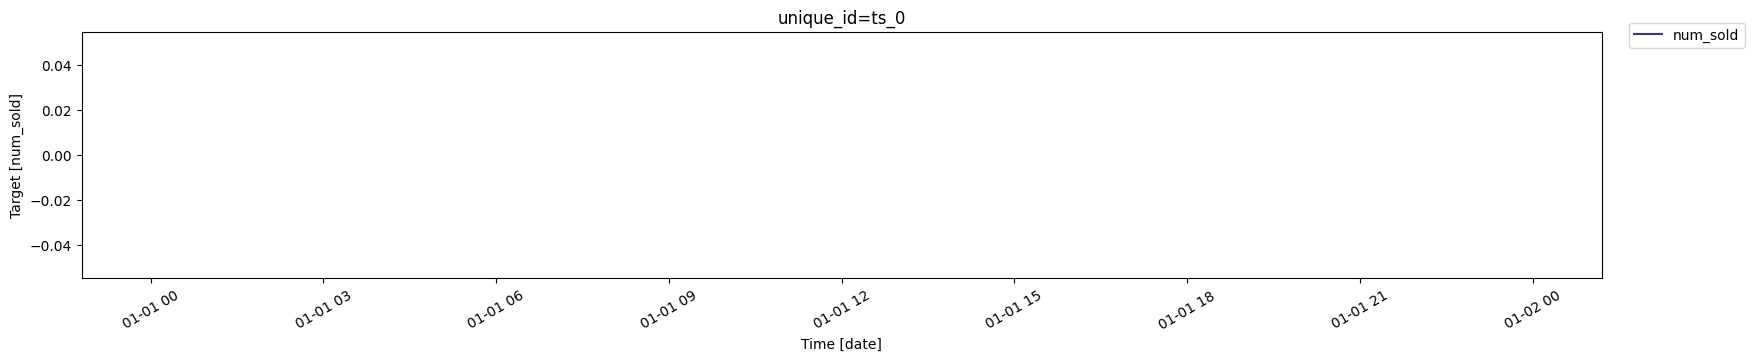

In [11]:
nixtla_client.plot(df_Can_DS_HG, time_col='date', target_col='num_sold')

In [12]:
df_Can_DS_Kag = df_Can_DS[df_Can_DS['product']=='Kaggle']
df_Can_DS_Kag

,id,date,country,store,product,num_sold
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
91,91,2010-01-02,Canada,Discount Stickers,Kaggle,881.0
181,181,2010-01-03,Canada,Discount Stickers,Kaggle,1003.0
271,271,2010-01-04,Canada,Discount Stickers,Kaggle,744.0
361,361,2010-01-05,Canada,Discount Stickers,Kaggle,707.0
...,...,...,...,...,...,...
229681,229681,2016-12-27,Canada,Discount Stickers,Kaggle,694.0
229771,229771,2016-12-28,Canada,Discount Stickers,Kaggle,810.0
229861,229861,2016-12-29,Canada,Discount Stickers,Kaggle,856.0
229951,229951,2016-12-30,Canada,Discount Stickers,Kaggle,939.0


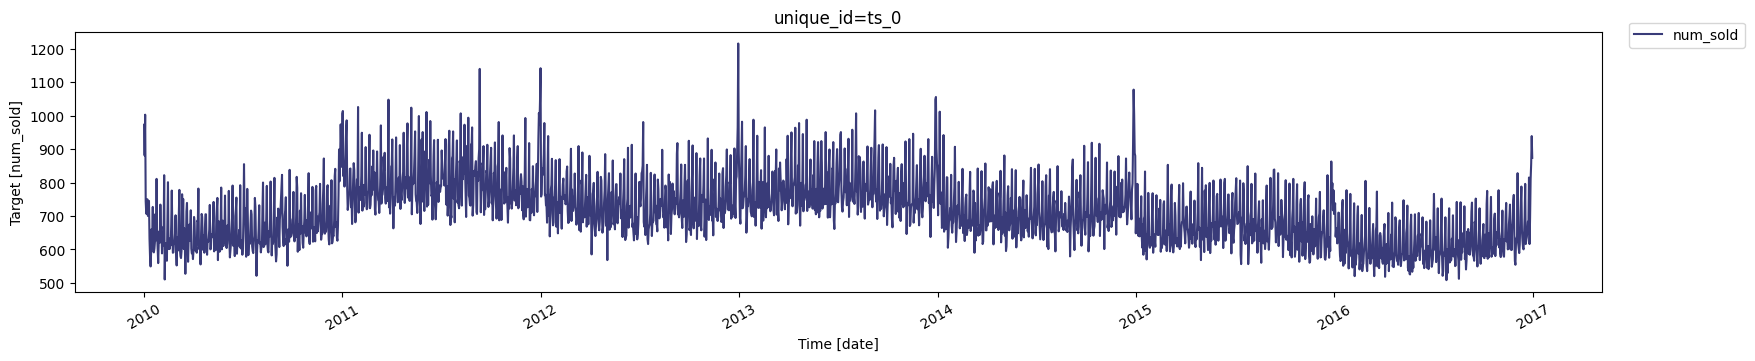

In [13]:
nixtla_client.plot(df_Can_DS_Kag, time_col='date', target_col='num_sold')

# 4 Forecasting Sales for the Next 3 years

In [14]:
timegpt_fcst_df = nixtla_client.forecast(df=df_Can_DS_Kag, h=365*3, freq='D', time_col='date', target_col='num_sold', model='timegpt-1-long-horizon')
timegpt_fcst_df

INFO:nixtla.nixtla_client:Validating inputs...
/opt/miniconda3/envs/envai/lib/python3.11/site-packages/nixtla/nixtla_client.py:383: UserWarning: `df` contains the following exogenous features: ['id', 'country', 'store', 'product'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


,date,TimeGPT
0,2017-01-01,872.62573
1,2017-01-02,702.98010
2,2017-01-03,684.78687
3,2017-01-04,691.62646
4,2017-01-05,696.28485
...,...,...
1090,2019-12-27,664.48126
1091,2019-12-28,692.58170
1092,2019-12-29,714.54270
1093,2019-12-30,655.65686


<font size="3">h: Horizons is the number of steps ahead to forecast.<font>

https://docs.nixtla.io/docs/getting-started-timegpt_quickstart

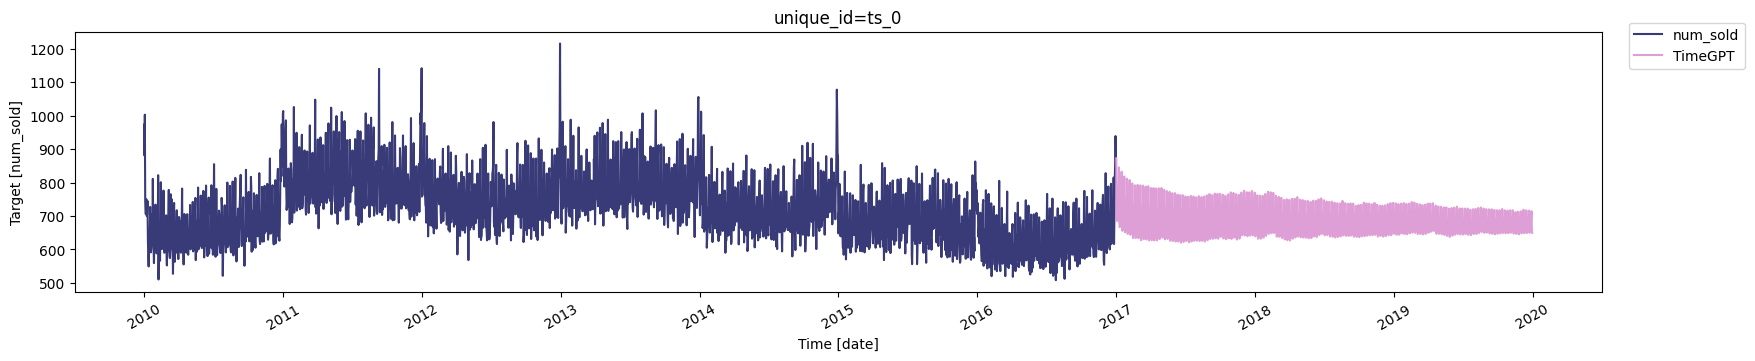

In [16]:
nixtla_client.plot(df_Can_DS_Kag, timegpt_fcst_df, time_col='date', target_col='num_sold')

# 5 Improve Forecast Accuracy

## 5a. Add Finetune Steps

In [17]:
timegpt_fcst_finetune_df_10 = nixtla_client.forecast(
    df=df_Can_DS_Kag, h=365*3, finetune_steps=10,
    time_col='date', target_col='num_sold', model='timegpt-1-long-horizon'
)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: D
/opt/miniconda3/envs/envai/lib/python3.11/site-packages/nixtla/nixtla_client.py:383: UserWarning: `df` contains the following exogenous features: ['id', 'country', 'store', 'product'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


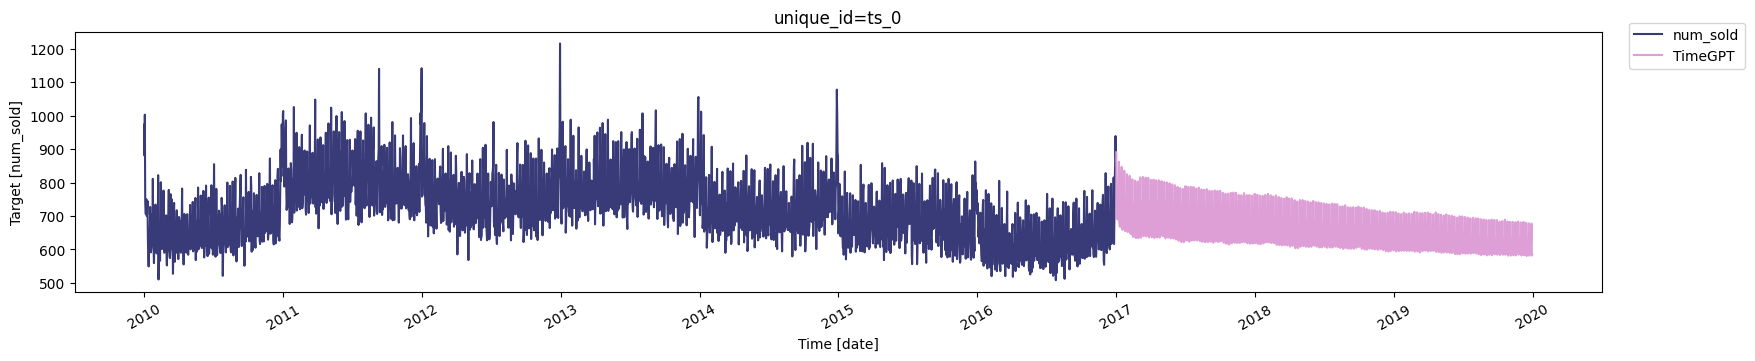

In [18]:
nixtla_client.plot(
    df_Can_DS_Kag, timegpt_fcst_finetune_df_10, 
    time_col='date', target_col='num_sold',
)

<font size="3">Set finetune_steps to 30.<font>

In [19]:
timegpt_fcst_finetune_df_30 = nixtla_client.forecast(
    df=df_Can_DS_Kag, h=365*3, finetune_steps=30,
    time_col='date', target_col='num_sold', model='timegpt-1-long-horizon'
)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: D
/opt/miniconda3/envs/envai/lib/python3.11/site-packages/nixtla/nixtla_client.py:383: UserWarning: `df` contains the following exogenous features: ['id', 'country', 'store', 'product'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


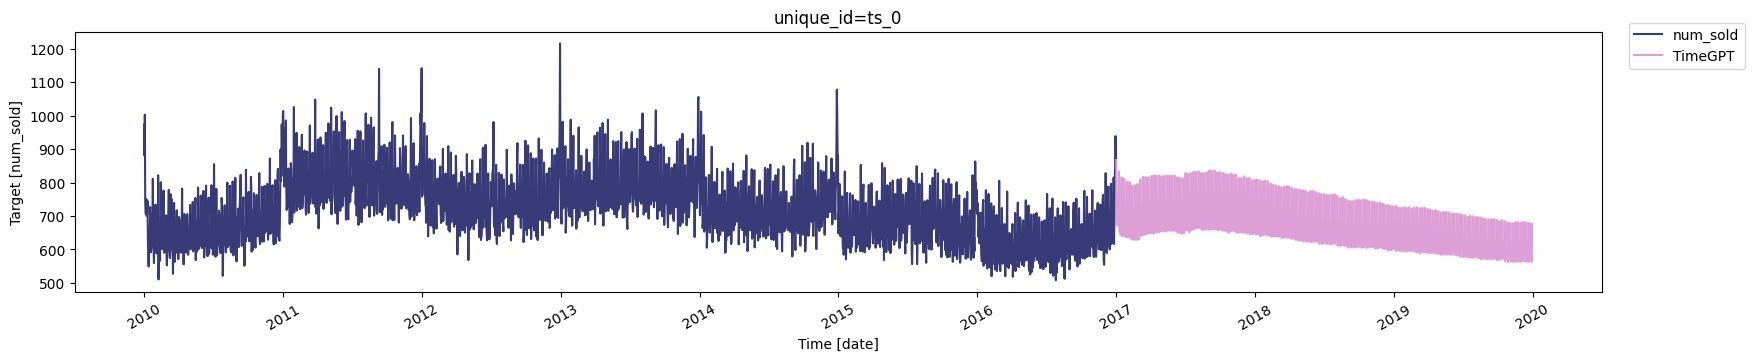

In [20]:
nixtla_client.plot(
    df_Can_DS_Kag, timegpt_fcst_finetune_df_30, 
    time_col='date', target_col='num_sold',
)

<font size="3">Set finetune_steps to 50.<font>

In [19]:
timegpt_fcst_finetune_df_50 = nixtla_client.forecast(
    df=df_Canada_DS_Kag, h=365*3, finetune_steps=50,
    time_col='timestamp', target_col='num_sold', model='timegpt-1-long-horizon'
)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: D
/opt/miniconda3/envs/envai/lib/python3.11/site-packages/nixtla/nixtla_client.py:383: UserWarning: `df` contains the following exogenous features: ['id', 'country', 'store', 'product'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


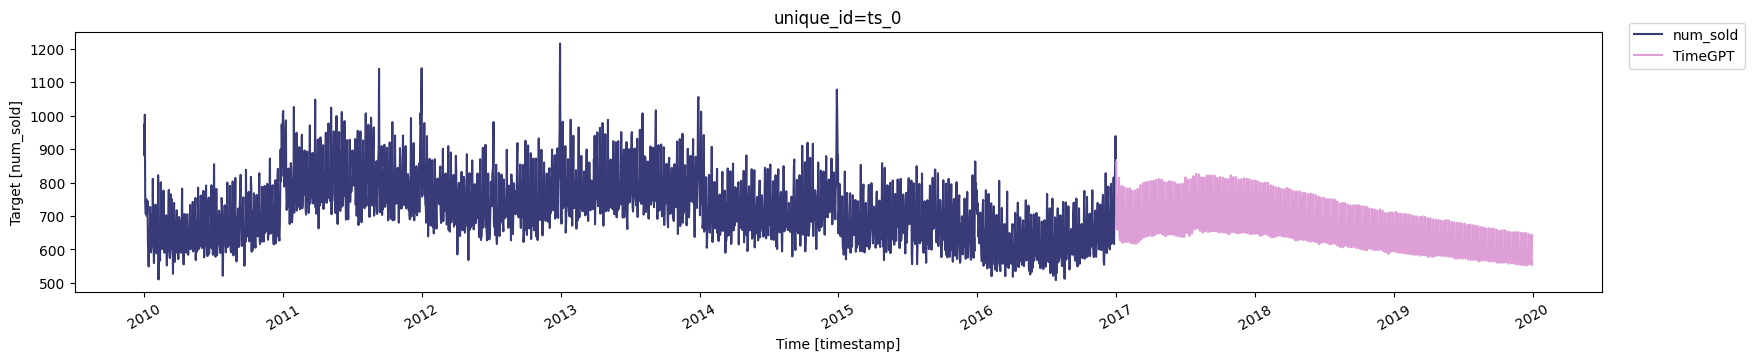

In [20]:
nixtla_client.plot(
    df_Canada_DS_Kag, timegpt_fcst_finetune_df_50, 
    time_col='timestamp', target_col='num_sold',
)

<font size="3">The forecast does not seem better than that with finetune_steps 30.<font>

## 5b. Finetune with Different Loss Function

<font size="3">According to competiton's overview, submissions are evaluated using the Mean Absolute Percentage Error (MAPE).<font>

<font size="3">According to Nixtla's documentation, Mean absolute error (MAE), Mean squared error (MSE), Root mean squared error (RMSE), Mean absolute percentage error (MAPE) and Symmmetric mean absolute percentage error (sMAPE) are supported.<font>

https://docs.nixtla.io/docs/tutorials-fine_tuning_with_a_specific_loss_function

In [21]:
timegpt_fcst_finetune_mape_df = nixtla_client.forecast(
    df=df_Can_DS_Kag, 
    h=365*3, 
    finetune_steps=30,
    finetune_loss='mape',   # Set your desired loss function
    time_col='date', 
    target_col='num_sold',
    model='timegpt-1-long-horizon'
)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: D
/opt/miniconda3/envs/envai/lib/python3.11/site-packages/nixtla/nixtla_client.py:383: UserWarning: `df` contains the following exogenous features: ['id', 'country', 'store', 'product'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


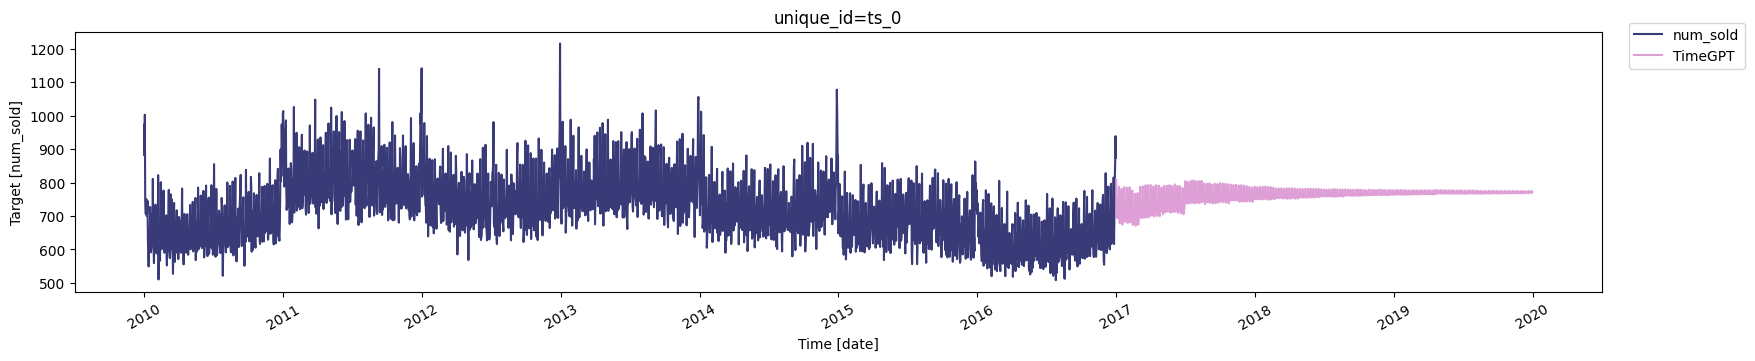

In [22]:
nixtla_client.plot(
    df_Can_DS_Kag, timegpt_fcst_finetune_mape_df, 
    time_col='date', target_col='num_sold',
)

## 5c. Adjust the number of parameters being fine-tuned

In [23]:
fcst_finetune_depth_df = nixtla_client.forecast(df=df_Can_DS_Kag,
                                                h=365*3,
                                                finetune_steps = 30,
                                                finetune_depth=2,
                                                finetune_loss = 'mape',
                                                level=[90, 95],
                                                time_col='date', 
                                                target_col='num_sold',
                                                model='timegpt-1-long-horizon')

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Inferred freq: D
/opt/miniconda3/envs/envai/lib/python3.11/site-packages/nixtla/nixtla_client.py:383: UserWarning: `df` contains the following exogenous features: ['id', 'country', 'store', 'product'], but `X_df` was not provided and they were not declared in `hist_exog_list`. They will be ignored.
  warnings.warn(
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


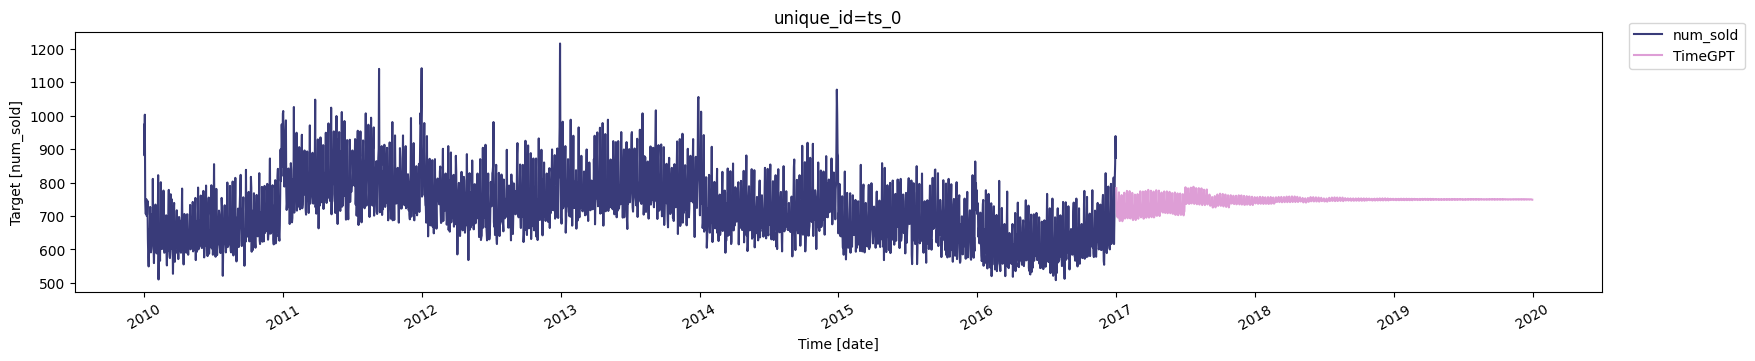

In [25]:
nixtla_client.plot(
    df_Can_DS_Kag, fcst_finetune_depth_df, 
    time_col='date', target_col='num_sold',
)